In [ ]:
!unzip "/content/car_Number_plate_detection.v1-roboflow-instant-1--eval-.yolov11.zip"

Archive:  /content/car_Number_plate_detection.v1-roboflow-instant-1--eval-.yolov11.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/00x500_jpg.rf.df428f5ba93616ce147a8a396cbb92da.jpg  
 extracting: test/images/20200222_164603_jpg.rf.b5587bad078aa8c286ba4ed423b9e50a.jpg  
 extracting: test/images/20200222_165402_jpg.rf.6d58ef4c716cd74837b1c3ed18117bae.jpg  
 extracting: test/images/20200222_165603_jpg.rf.1e5bb9d2d2d23a90f9ebcfec966c41f7.jpg  
 extracting: test/images/20200222_165932_jpg.rf.4f98d6f451be8fb0a96de8319788a3cc.jpg  
 extracting: test/images/20200222_172118_jpg.rf.fd29cfe302de9733b797486c61840354.jpg  
 extracting: test/images/20200222_173835_jpg.rf.57eb6d3596951fd61a55f5066110328c.jpg  
 extracting: test/images/20200222_173841_jpg.rf.4013b6e6117087d647eff3e3b6939404.jpg  
 extracting: test/images/20200222_174125_jpg.rf.cf848ceb8cce84fb211

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolo11n.pt')

In [ ]:
model.train(data="/content/data.yaml",epochs=200,imgsz=640)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a0c9c499a60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model = YOLO("/content/runs/detect/train4/weights/best.pt")


image 1/1 /content/car_image_c.webp: 640x640 1 Number-plate, 9.1ms
Speed: 2.4ms preprocess, 9.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


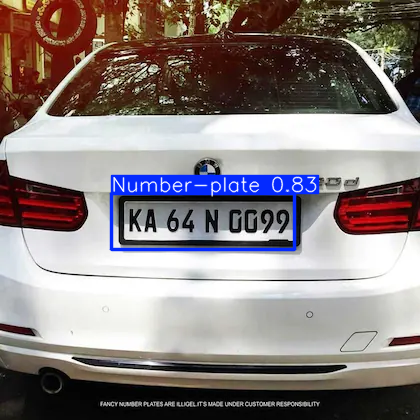

In [ ]:
results = model("/content/car_image_c.webp", conf=0.5)
results[0].show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/Number_plate_detection model/best.pt")

In [ ]:
img = cv2.imread('/content/car_image_c.webp')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model(img_rgb,save=True)


0: 640x640 1 Number-plate, 20.0ms
Speed: 3.9ms preprocess, 20.0ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict



image 1/1 /content/car_image_c.webp: 640x640 1 Number-plate, 10.7ms
Speed: 2.6ms preprocess, 10.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


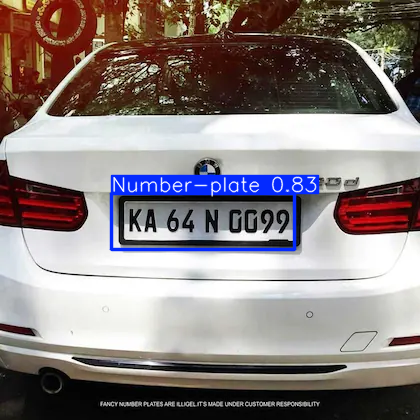

In [ ]:
results = model("/content/car_image_c.webp", conf=0.5)
results[0].show()

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 36.3 MB/s eta 0:00:00


In [ ]:
import easyocr

In [ ]:
dir(easyocr)

['Reader',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'config',
 'easyocr',
 'imgproc',
 'recognition',
 'utils']

In [ ]:
from ultralytics import YOLO
import cv2
import easyocr
import matplotlib.pyplot as plt
import os

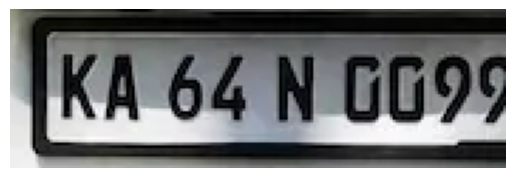

In [ ]:
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        plate = img_rgb[y1:y2, x1:x2]
        plt.imshow(plate)
        plt.axis('off')

In [ ]:
reader = easyocr.Reader(['en'])
ocr_result = reader.readtext(plate)
for (_, text, prob) in ocr_result:
    print(f'Text: {text}, Confidence: {prob:.2f}')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteText: KA 64 N 009P, Confidence: 0.33


(np.float64(-0.5), np.float64(419.5), np.float64(419.5), np.float64(-0.5))

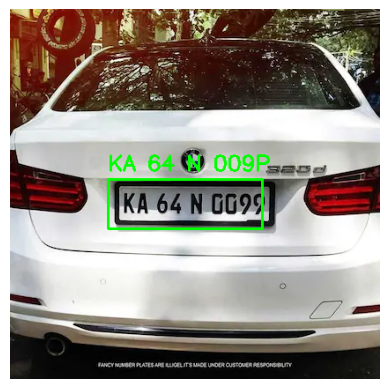

In [ ]:
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        plate = img_rgb[y1:y2, x1:x2]
        ocr = reader.readtext(plate)
        for (_, text, prob) in ocr:
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(img_rgb, text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
plt.imshow(img_rgb)
plt.axis('off')

Text: KA 64 N 009S, Confidence: 0.38


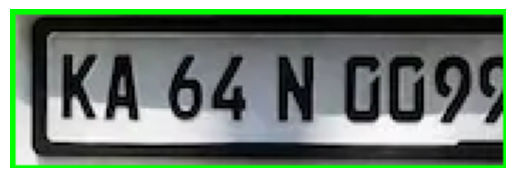

In [ ]:
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        plate = img_rgb[y1:y2, x1:x2]
        ocr = reader.readtext(plate)
        for (_, text, prob) in ocr:
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(img_rgb, text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
plt.imshow(plate)
plt.axis('off')



reader = easyocr.Reader(['en'])
ocr_result = reader.readtext(plate)
for (_, text, prob) in ocr_result:
    print(f'Text: {text}, Confidence: {prob:.2f}')